## __Data Science: Capstone Part 1: Lightning Talk 1__

### Overview

In the field of data science, good projects are practical. Your capstone project should be manageable and affect a real world audience. This might be a domain you are familiar with, a particular interest you have, something that affects a community you are involved in, or an area that relates to a field you wish to work in.

One of the best ways to test ideas quickly is to share them with others. A good data scientist has to be comfortable discussing ideas and presenting to audiences. That's why for Part 1 of your Capstone project, you'll be preparing a lightning talk on some potential interest areas and datasets.

This deliverable will provide you with guidance to help you select an awesome topic and begin to build a polished Capstone project.

__Goal__: Host a lightning talk presentation describing at least three project proposals, including associated data, problem statement, goals, approach, and basic EDA.

### REQUIRED

__Foreach Topic__:
- Problem Statement ([Reference](https://github.com/ga-bahrain/dsb-pt3-bahrain-2026/blob/main/modules/supervised-machine-learning/0.How%20to%20Frame%20a%20Data%20Science%20Problem/ML-Framing-a-Data-Science-Problem.pdf))
- Goals
- Approach
- Data Source(s)
- Data Info. (basic EDA)

Dataset should have __15k+__ rows and __10+__ columns

___Remember, if you can't find data to support your topic, then you can't move forward.___

# Topic 1 : flight price predictions

## Problem Statement
#### To analyze and predict flight ticket prices based on numerical and categorical features such as airline, route,travel class,
####  duration, and time before departure using exploratory data analysis and machine learning techniques
#### , and develop a predictive model using them.


## Data Info
Data Source :https://www.kaggle.com/datasets/ranafayezz/flight-price-prediction-df

## Data Dictionary
| Column           | Type                 | Description                           |
| ---------------- | -------------------- | ------------------------------------- |
| airline          |(String) | Airline company operating the flight  |
| flight           |(String) | Flight stores information regarding the plane's flight code|
| source_city      |(String) | Departure city                        |
| departure_time   |(String) | Scheduled departure time category     |
| stops            |(String) | Number of stops during the journey    |
| arrival_time     |(String) | Scheduled arrival time category       |
| destination_city |(String) | Destination city                      |
| class            |(String) | Travel class (Economy or Business)    |
| duration         |(Float)  | Flight duration in hours              |
| days_left        |(Integer)| Number of days left before departure  |
| price            |(Integer)| Flight ticket price (Target Variable) |




In [44]:
# start you EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv('flight price predections.csv')
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [46]:
df = df.drop(columns=["Unnamed: 0"])

### We dropped the (uunamed:0) column because it is just index row

In [47]:
df.shape

(300153, 11)

### we have more than 30K records, 11 columns: 10 features with a target (price)

In [48]:
### Our target column is price it represents the flight ticket price

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   flight            300153 non-null  str    
 2   source_city       300153 non-null  str    
 3   departure_time    300153 non-null  str    
 4   stops             300153 non-null  str    
 5   arrival_time      300153 non-null  str    
 6   destination_city  300153 non-null  str    
 7   class             300153 non-null  str    
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 25.2 MB


### Our target is price it represets the flight ticket price. It is continuous value so we can not say it is balanced or not.

In [50]:
df['price'].describe()

count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

#### min price is 1105 and max is 123071, this huge gap create a big difference between mean  and median making the mean much higher

#### Our targe is numerical (float)

### Null (missing) values:

In [52]:
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

#### No missing values were detected in the dataset. Therefore, no imputation or row removal techniques are required.

In [53]:
df["flight"].nunique()

1561

#### The flight feature contains 1,561 unique flight codes across +30k observations.
#### This indicates that the feature has high cardinality and may require careful encoding during machine learning model development.

### Categorical Features(8): 
#### airline
#### flight
#### source_city
#### departure_time
#### stops
#### arrival_time
#### destination_city
### Numerical Features (2):
#### duration
#### days_left
### Target
#### price

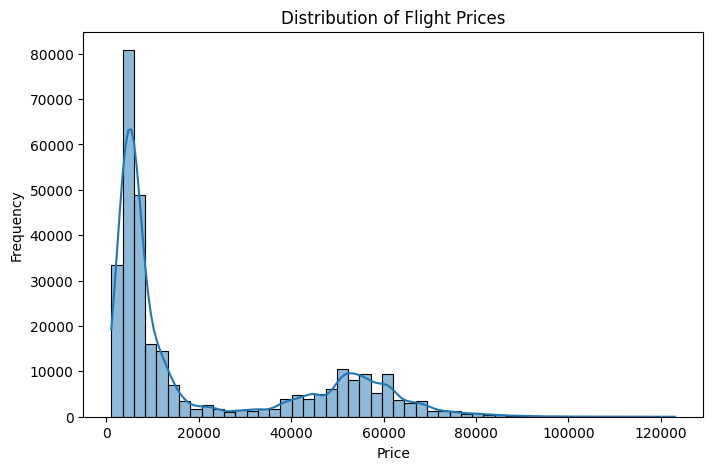

In [54]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=50, kde=True)

plt.title("Distribution of Flight Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

#### we can see the prices above 80K are very rare and above 100K are clearly outliers

## correlations:

In [55]:
corr = df.select_dtypes(include=["int64", "float64"]).corr()

corr["price"].sort_values(ascending=False)

price        1.000000
duration     0.204222
days_left   -0.091949
Name: price, dtype: float64

#### The correlation analysis revealed that the numerical features have weak relationships with the target variable (price).
#### Flight duration showed the highest positive correlation (r = 0.204) which is weak.
#### while days left before departure showed a very weak -almost not significant- negative correlation (r = -0.092).
#### These results suggest that numerical variables alone do not strongly explain ticket prices.
#### Therefore, it is likely that categorical variables play a more significant role in determining flight prices.

### To examine this theory we use plot boxes for all categorical columns to compare between classes and categories:

In [56]:

def analyze_categorical(df, column, target="price"):
    
 
    plt.figure(figsize=(8,4))
    
    sns.boxplot(
        data=df,
        x=column,
        y=target
    )
    
    plt.xticks(rotation=45)
    plt.title(f"{target} by {column}")
    
    plt.show()

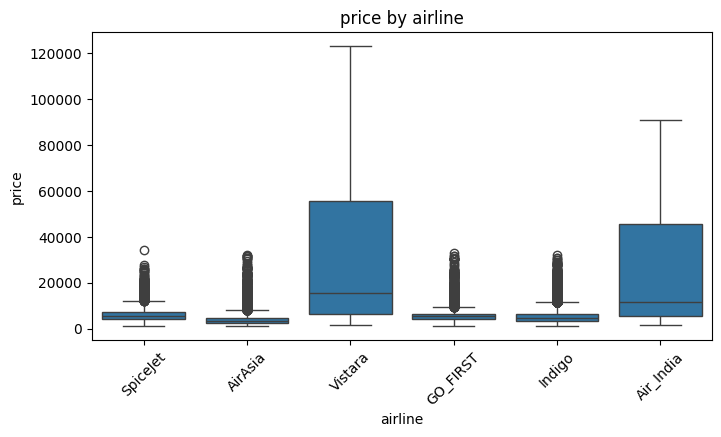

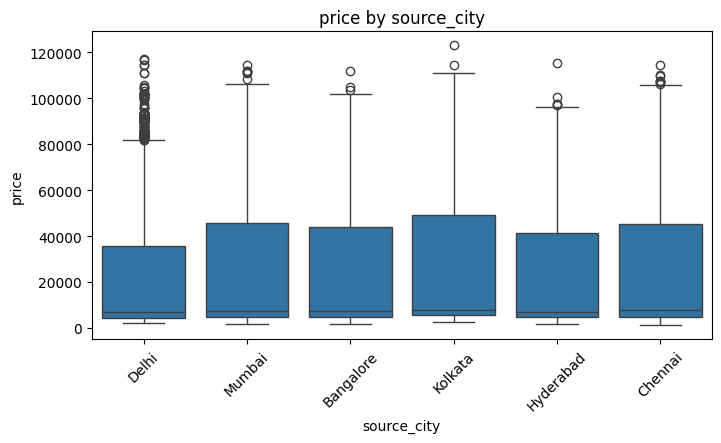

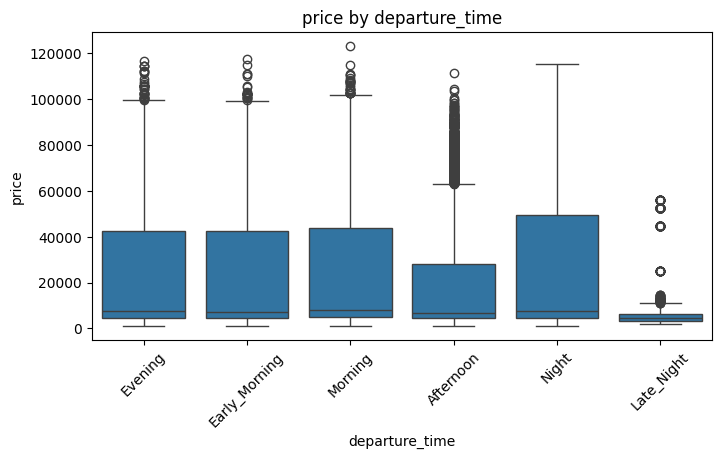

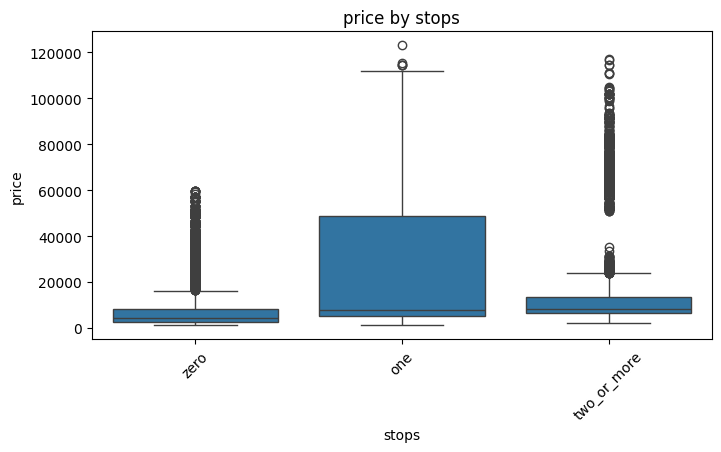

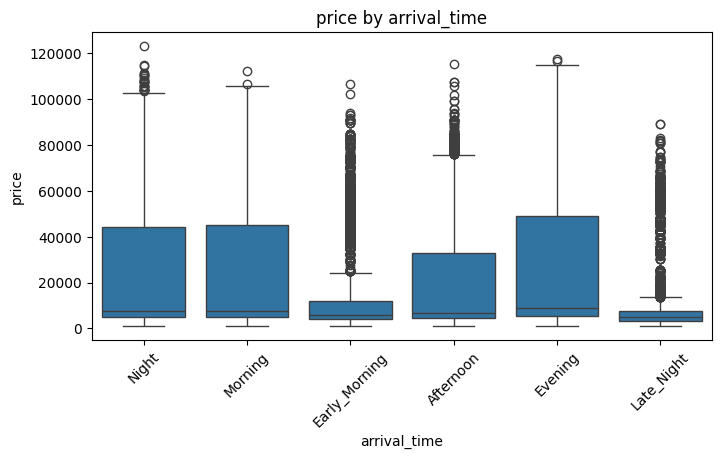

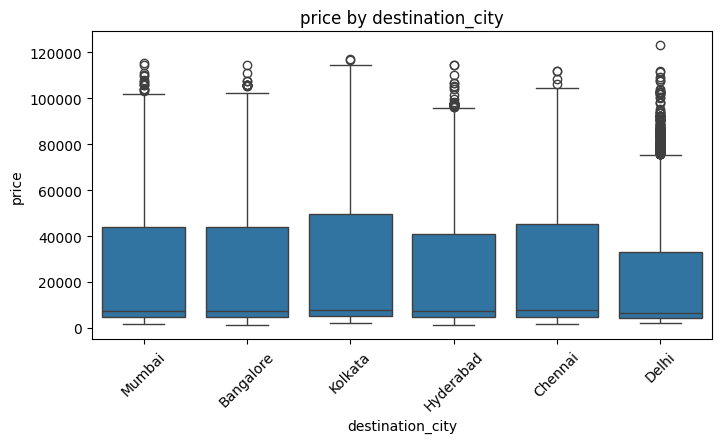

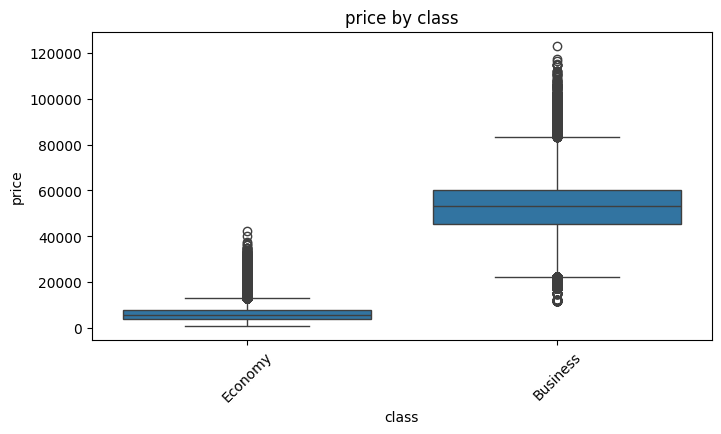

In [57]:
categorical_cols = [
    "airline",
    "source_city",
    "departure_time",
    "stops",
    "arrival_time",
    "destination_city",
    "class"
]

for col in categorical_cols:
    analyze_categorical(df, col)

#### we can see there is a significant difference between airline companies prices (vistara and Air_india are expensive compared to others)
#### The source city is not playing a significant role with the price
#### The price by departure_time is significant mostly if the time is late night and a bit at afternoon 
#### we can see if the number of stops is one it is the most expensive
#### If arrival_time is late night and early morning it is significantly cheaper.
#### The destination is not playing a big role in price difference but delhi is the cheapest
#### The class is playing a very significant role we can clearly see the huge price difference between economy and business class prices

## Outliers

In [58]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["price"] < lower_bound) |
    (df["price"] > upper_bound)
]

print("Number of outliers:", len(outliers))



Number of outliers: 123


In [59]:
lower_bound

np.float64(-51824.0)

In [60]:
upper_bound

np.float64(99128.0)

#### The IQR method was used to detect outliers in the price variable. The computed lower bound was negative, which is not meaningful in the context of flight prices, as prices cannot be below zero.
#### Therefore, no lower-bound outliers exist.
#### The upper bound identifies high-priced tickets, as potential outliers. These values were retained because they represent valid premium pricing rather than data errors.
#### also 123 records are very low compared to more than 30K records they shouldnt significantly affect the analysis and model training.

In [61]:
### we will get the same result even if we remove the lower bound from the equation: 
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outliers = df[df["price"] > upper_bound]

print(len(outliers))

123


In [62]:
### This indicates the outliers 

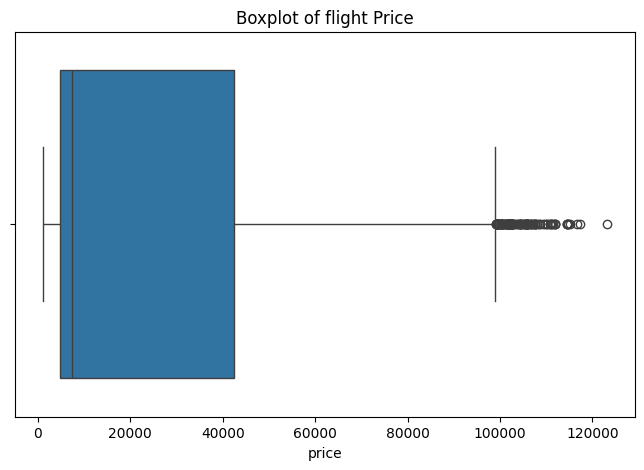

In [74]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["price"]
)

plt.title("Boxplot of flight Price")

plt.show()

#### Outliers were assessed using boxplots and the Interquartile Range (IQR) method.
For the price, values below about 100K were identified as normal prices.
The outliers were not removed because they may represent genuine cases of high price flight tickets rather than data-entry errors.
Since the dataset contains +30K records, a small number of outliers (123 only) is unlikely to significantly impact the analysis.while robust modeling techniques or scaling methods could be considered if they negatively affect predictive performance

In [64]:
# What is your target column and what does it represent?
# Is your target categorical or continuous? is it balanced (Plot the distribution)?
# What types of features do you have (categorical / numerical)? how many of each ?
# How many null values does each feature have? what's your plan for each?
# Which features are most correlated with your target, and with each other?
# Are there outliers? how would you handle them?

# Topic 2 : work productivity dataset

## Problem Statement
To analyze a remote work dataset and develop a predictive model for employee productivity based on demographic, work-related, and well-being factors such as age, industry, work mode, working hours, sleep habits, exercise frequency, mental health, job satisfaction, and salary. Through exploratory data analysis and machine learning techniques, the project seeks to identify the key drivers of productivity and evaluate how accurately employee productivity can be predicted.

## Data Info
Data Source :https://www.kaggle.com/datasets/saitejabandaruin/remote-work-productivity-dataset-2025

## Data Dictionary
| Column Name                 | Data Type | Description                                                                                 
| --------------------------- | --------- | ------------------------------------------------------------------------------------------- 
| employee_id                 | string    | Unique identifier assigned to each employee.                                                
| age                         | integer   | Employee's age in years.                                                                    
| country                     | string    | Country where the employee is located or employed.                                          
| industry                    | string    | Industry sector in which the employee works.                                                
| work_mode                   | string    | Employee's working arrangement (e.g., remote, hybrid, or on-site).                          
| year                        | integer   | Year in which the employee data was recorded.                                               
| weekly_hours_worked         | float     | Average number of hours worked per week.                                                    
| tasks_completed             | integer   | Total number of tasks completed during the reporting period.                                
| productivity_score          | integer   | Quantitative measure of employee productivity. Higher values indicate greater productivity. 
| sleep_hours_avg             | float     | Average number of hours slept per day.                                                      
| exercise_frequency_per_week | integer   | Number of exercise sessions performed per week.                                             
| mental_health_score         | integer   | Quantitative measure of mental well-being. Higher values indicate better mental health.     
| burnout_level               | string    | Categorical assessment of employee burnout status.                                          
| job_satisfaction            | float     | Employee job satisfaction score. Higher values indicate greater satisfaction.               
| salary_usd                  | float     | Employee salary expressed in U.S. dollars.                                                  


In [65]:
df2 = pd.read_csv('remote_work_productivity_dataset.csv')
df2.head()

,employee_id,age,country,industry,work_mode,year,weekly_hours_worked,tasks_completed,productivity_score,sleep_hours_avg,exercise_frequency_per_week,mental_health_score,burnout_level,job_satisfaction,salary_usd
0,EMP000001,59,France,Retail,Hybrid,2024,53.9,69,85,4.9,4,91,High,9.3,83499.93
1,EMP000002,44,Italy,Healthcare,On-site,2021,49.5,73,84,4.3,3,83,Medium,8.5,30093.45
2,EMP000003,45,Italy,Healthcare,On-site,2023,38.7,83,100,7.1,5,100,Low,9.4,73963.42
3,EMP000004,23,France,Tech,Hybrid,2023,55.8,103,92,7.4,0,97,High,8.7,143064.21
4,EMP000005,22,USA,Education,Hybrid,2023,50.5,87,92,6.2,1,87,Medium,9.0,34126.62


In [66]:
df2.shape

(50000, 15)

### We have 50K records and 15 columns (1 target and 14 features)

In [67]:
df2["productivity_score"].unique()

array([ 85,  84, 100,  92,  90,  73,  83,  89,  94,  86,  78,  91,  88,
        95,  99,  97,  87,  96,  75,  98,  76,  82,  81,  79,  74,  93,
        77,  80,  71,  70,  69,  72,  68,  66,  67,  64,  65,  60,  62,
        63])

### Our target column is "productivity_score" which is continuous value between 60-100

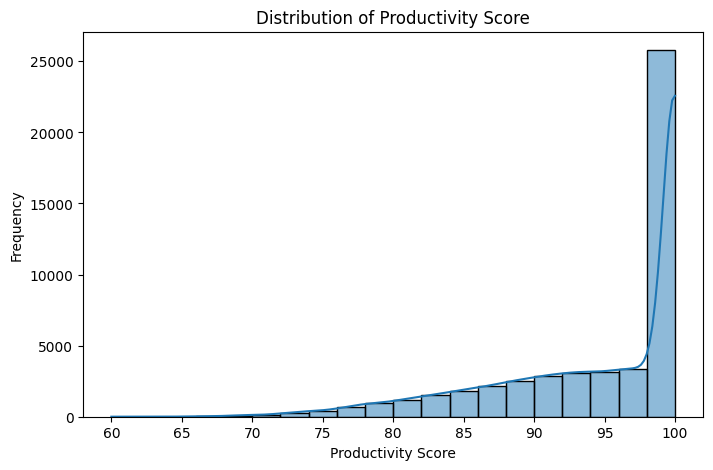

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    df2["productivity_score"],
    bins=20,
    kde=True
)

plt.title("Distribution of Productivity Score")
plt.xlabel("Productivity Score")
plt.ylabel("Frequency")
plt.show()

### we can see the results are very unbalanced and score of 100 is the most frequent score

In [69]:
corr = df2.select_dtypes(include="number").corr()

corr["productivity_score"]\
    .sort_values(ascending=False)

productivity_score             1.000000
mental_health_score            0.713322
sleep_hours_avg                0.576854
job_satisfaction               0.562137
tasks_completed                0.548097
age                            0.002194
salary_usd                    -0.003038
exercise_frequency_per_week   -0.003098
year                          -0.004457
weekly_hours_worked           -0.556147
Name: productivity_score, dtype: float64

In [70]:
df2["productivity_score"].describe()

count    50000.000000
mean        94.374660
std          7.177052
min         60.000000
25%         90.000000
50%         98.000000
75%        100.000000
max        100.000000
Name: productivity_score, dtype: float64

### Interpretation

Our target variable is continuous, but it is heavily concentrated near the upper limit (100).

### Observations:
The median is 98, very close to the maximum, and also the mean is 94.4 very close to 100.
The distribution is left-skewed because most values are high and fewer values are low.


#### we can see the most correlated feature is  mental_health_score <u><b>possitively correlated</u></b> about 0.71with the target
#### then the significant other <u><b>positive correlated features</u></b>:
#### sleep_hours_avg around 0.58
#### job_satisfaction around 0.56
#### tasks_completed around 0.55
#### <b><u>negativly affecting feature:</u></b> weekly_hours_worked around -0.56

In [73]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employee_id                  50000 non-null  str    
 1   age                          50000 non-null  int64  
 2   country                      50000 non-null  str    
 3   industry                     50000 non-null  str    
 4   work_mode                    50000 non-null  str    
 5   year                         50000 non-null  int64  
 6   weekly_hours_worked          50000 non-null  float64
 7   tasks_completed              50000 non-null  int64  
 8   productivity_score           50000 non-null  int64  
 9   sleep_hours_avg              50000 non-null  float64
 10  exercise_frequency_per_week  50000 non-null  int64  
 11  mental_health_score          50000 non-null  int64  
 12  burnout_level                50000 non-null  str    
 13  job_satisfaction           

### categorical features (4)
#### country
#### industry 
#### work_mode
#### burnout_level

### numeric features (9)
#### age
#### year
#### weekly_hours_worked
#### tasks_completed
#### sleep_hours_avg
#### requency_per_week
#### mental_health_score
#### job_satisfaction
#### salary_usd

### Target 
#### productivity_score 

#### we have categorical features which are: country, industry, work_mode and burnout_level
#### also we have numeric features: age, year,weekly_hours_worked,tasks_completed,sleep_hours_avg,exercise_frequency_per_week, 
#### mental_health_score,job_satisfaction,salary_usd 

In [74]:
df2.isnull().sum()

employee_id                    0
age                            0
country                        0
industry                       0
work_mode                      0
year                           0
weekly_hours_worked            0
tasks_completed                0
productivity_score             0
sleep_hours_avg                0
exercise_frequency_per_week    0
mental_health_score            0
burnout_level                  0
job_satisfaction               0
salary_usd                     0
dtype: int64

#### we have no null values so we dont need to deal with nulls

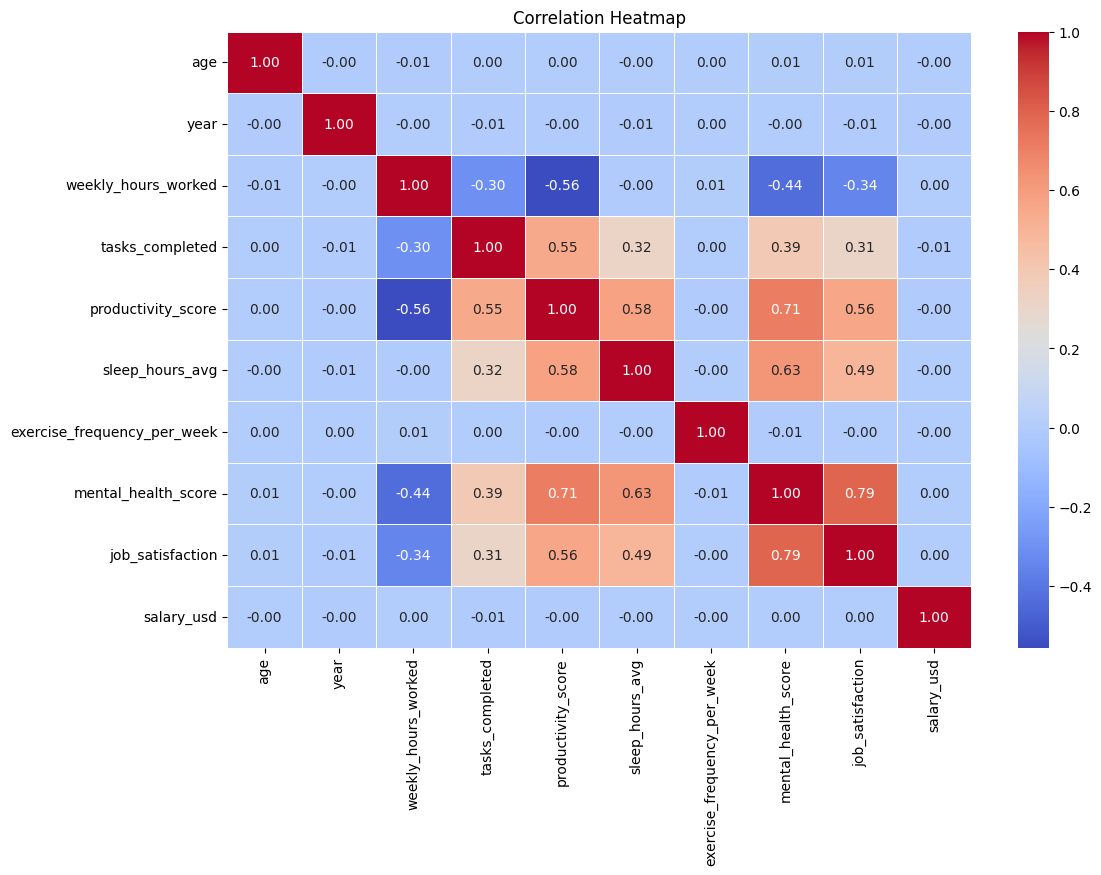

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df2.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

#### we can see the most correlated feature is  mental_health_score <u><b>possitively correlated</u></b> about 0.71with the target
#### then the significant other <u><b>positive correlated features</u></b>:
#### sleep_hours_avg around 0.58
#### job_satisfaction around 0.56
#### tasks_completed around 0.55
#### <b><u>negativly affecting feature:</u></b> weekly_hours_worked around -0.56 
## -----------------------------------------------------------------------------------------
#### we also can see how mental_health_score is hightly correlated with job_satisfaction(0.79) and sleep_hours_avg(0.63)
#### also there is a medium correlaion between task_completed and job_satisfaction(0.55) 
#### year, age, exercise_frequency_per_week and salary almost has no correlation with any other features


## Outliers: 

In [79]:
Q1 = df2["productivity_score"].quantile(0.25)
Q3 = df2["productivity_score"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df2[
    (df2["productivity_score"] < lower_bound) |
    (df2["productivity_score"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 728


In [80]:
lower_bound

np.float64(75.0)

In [81]:
upper_bound

np.float64(115.0)

#### the upper bound in more than the max productivity score so we can focous on the lower bound to identify the outliers

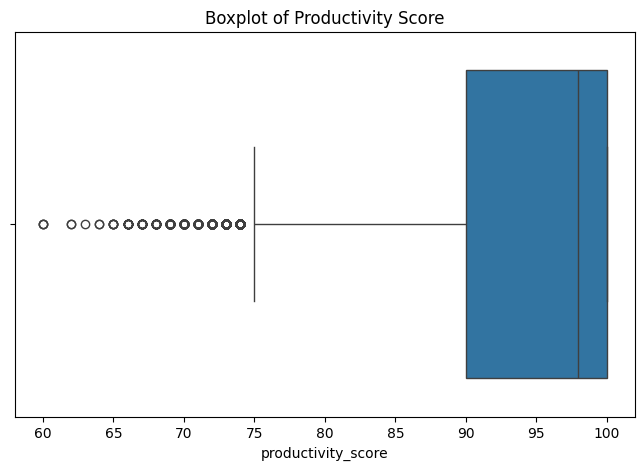

In [84]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df2["productivity_score"]
)

plt.title("Boxplot of Productivity Score")

plt.show()

#### Outliers were assessed using boxplots and the Interquartile Range (IQR) method.
For the productivity score, values below 75 were identified as potential outliers.
These observations were not removed because they may represent genuine cases of low employee productivity rather than data-entry errors.
Since the dataset contains 50,000 records, a small number of outliers (728 only) is unlikely to significantly impact the analysis.while robust modeling techniques or scaling methods could be considered if they negatively affect predictive performance

In [ ]:
# What is your target column and what does it represent?
# Is your target categorical or continuous? is it balanced (Plot the distribution)?
# What types of features do you have (categorical / numerical)? how many of each ?
# How many null values does each feature have? what's your plan for each?
# Which features are most correlated with your target, and with each other?
# Are there outliers? how would you handle them?